______________________________________________________________________________________________________
EJECUCIÓN
______________________________________________________________________________________________________

cd P3

python main.py

Flujo:
  1. Verifica BMW_Data.csv (si no existe, termina)
  2. Conecta a BBDD.sqlite
  3. Crea esquema (si es primera vez)
  4. Crea triggers
  5. Menú interactivo:
     1. CRUD (Insertar/Buscar/Actualizar/Eliminar/Mostrar)
     2. Analítica (CTE + Window + Batch)
     3. Auditoría (ver últimos cambios)
     0. Salir


───────────────────────────────────────────────────────────────────────────────
ARQUITECTURA: 4 TABLAS EN 3NF
───────────────────────────────────────────────────────────────────────────────

Cotizacion (tabla padre)

├─ cot_id (PK)
├─ fecha (UNIQUE, YYYY-MM-DD)
└─ adj_close (precio ajustado)

Precio (OHLC)

├─ open, high, low, close
└─ cot_id (FK) → Cotizacion

Volumen

├─ vol_id (PK)
├─ volume
└─ cot_id (FK) → Cotizacion

Auditoria (log automático)

├─ aud_id (PK)
├─ tabla, operacion, fecha_hora
├─ detalle (qué cambió)
└─ cot_id (FK) → Cotizacion

Relaciones:

1:1 entre padre-hijos, FK habilitadas

───────────────────────────────────────────────────────────────────────────────
VALIDACIÓN (3 NIVELES)
───────────────────────────────────────────────────────────────────────────────

NIVEL 1: Validadores (validaciones.py)

• validar_fecha() → Formato YYYY-MM-DD, rango 1900-9999
• validar_precio() → Decimal > 0, ≤ 10.000
• validar_adj_close() → Decimal ≤ Close
• validar_volumen() → Entero ≥ 0, ≤ 100.000.000
• validar_coherencia_ohlc() → High ≥ Low (crítico)

NIVEL 2: Códigos de Error (gestorerrores.py)

• EXITO = 0
• ERR_FECHA_* (-1 a -3)
• ERR_PRECIO_* (-10 a -12)
• ERR_VOLUMEN_* (-20 a -21)
• ERR_OHLC_* (-30 a -31)

Cada código → mensaje en español

NIVEL 3: BD

• UNIQUE en Cotizacion.fecha
• Foreign Keys
• Triggers automáticos

───────────────────────────────────────────────────────────────────────────────
MÓDULO CRUD (gestorbd.py)
───────────────────────────────────────────────────────────────────────────────

Insertar:

Pedir: fecha, open, high, low, close, adj_close, volume
Validar cada campo (reintenta si falla)
Validar coherencia OHLC (High ≥ Low es crítico)
Insertar en 3 tablas: Cotizacion → Precio → Volumen
Triggers registran en Auditoria

Buscar:

• JOIN 3 tablas, mostrar registro completo

Actualizar:

• Modificar Close y/o Volume
• Triggers registran cambios OLD → NEW en Auditoria

Eliminar:

• Orden: Precio → Volumen → Cotizacion (respeta FK)

───────────────────────────────────────────────────────────────────────────────
MÓDULO ANALÍTICA (gestorbd.py)
───────────────────────────────────────────────────────────────────────────────

CTE (Common Table Expressions)

Pregunta: Top 10 cierres por encima de la media de su año

WITH media_anual AS (
SELECT año, AVG(close) AS media
FROM datos
)

SELECT fecha, close, media, desviación
WHERE close > media
LIMIT 10

Window Functions

Pregunta: Volumen acumulado histórico por año

SELECT año,
SUM(volume) OVER (ORDER BY año) AS vol_acumulado
FROM datos

Modificación Masiva

Acción: Sube 2% close de días con volume > 10M

UPDATE Precio SET close *= 1.02

WHERE cot_id IN (
SELECT ...
FROM Volumen
WHERE volume > 10000000
)

→ Cada UPDATE dispara trigger → Auditoria registra

───────────────────────────────────────────────────────────────────────────────
TRIGGERS (AUDITORÍA AUTOMÁTICA)
───────────────────────────────────────────────────────────────────────────────

4 triggers que se disparan:

trg_precio_insert → INSERT en Precio → log en Auditoria

trg_precio_update → UPDATE en Precio → log (Close: old → new)

trg_volumen_insert → INSERT en Volumen → log en Auditoria

trg_volumen_update → UPDATE en Volumen → log (Volume: old → new)

───────────────────────────────────────────────────────────────────────────────
ESTRUCTURA DE ARCHIVOS
───────────────────────────────────────────────────────────────────────────────

main.py

• Punto de entrada: verifica CSV → conecta BD → menú
• 3 submenús: CRUD, Analítica, Auditoría
• Try-catch global (DatabaseError, Exception)

gestorbd.py (450+ líneas)

• crear_esquema(): DDL (CREATE TABLE)
• crear_triggers(): 4 triggers automáticos
• cargar_datos(): CSV → BD
• insertar / buscar / actualizar / eliminar: CRUD
• consulta_cte_sobre_media()
• consulta_window_functions()
• modificacion_masiva()
• ver_auditoria()

validaciones.py (110 líneas)

• 5 validadores (fecha, precio, adj_close, volumen, OHLC)
• pedir_campo(): helper para reintentos

gestorerrores.py (60 líneas)

• 13 códigos de error categorizados
• _mensajes: diccionario código → mensaje
• getMensaje(código)

BMW_Data.csv

• 7.212 registros (2014–2024)
• Columnas: Date, Open, High, Low, Close, Adj_Close, Volume

BBDD.sqlite

• Base de datos (creada automáticamente)

───────────────────────────────────────────────────────────────────────────────
CONCEPTO CLAVE: TRIGGERS (AUDITORÍA)
───────────────────────────────────────────────────────────────────────────────

Evento Tabla Trigger activo Resultado

INSERT Precio Precio trg_precio_insert Auditoria.insert

UPDATE Close Precio trg_precio_update Auditoria.update

INSERT Volume Volumen trg_volumen_insert Auditoria.insert

UPDATE Volume Volumen trg_volumen_update Auditoria.update

───────────────────────────────────────────────────────────────────────────────
MANEJO DE ERRORES
───────────────────────────────────────────────────────────────────────────────

Nivel 1: main()

try-except sqlite3.DatabaseError → errores de BD

try-except Exception → fallos genéricos

Nivel 2: Inicialización

try: verificar tabla Cotizacion

except: recrear esquema si falta

Nivel 3: Menú

try: ejecutar submenú

except: capturar errores, continuar

## MODELO ENTIDAD RELACION

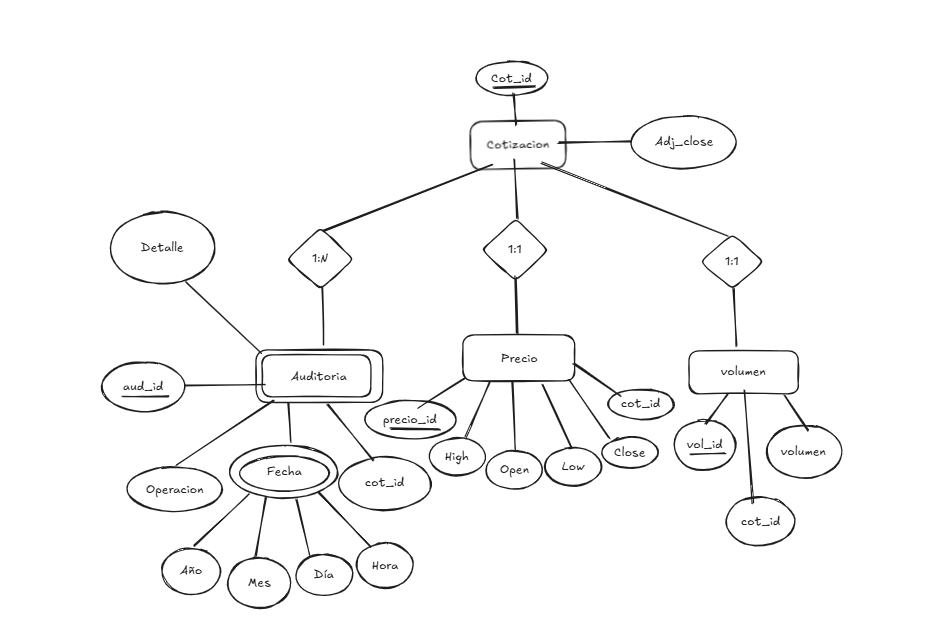

## MODELO RELACIONAL

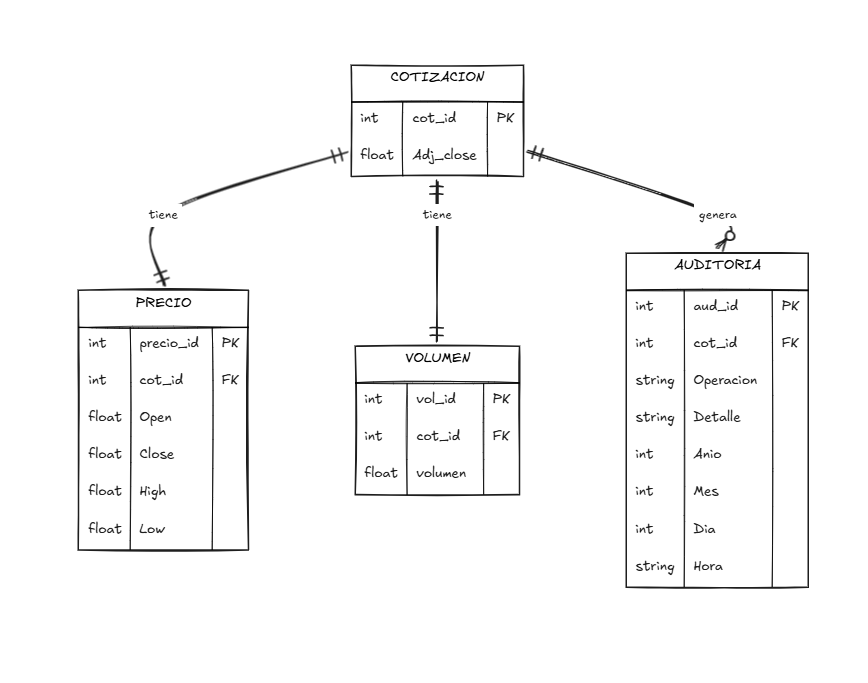

## PRUEBA DE ESCRITORIO — BD RELACIONAL BMW  
### Resumen de Entradas y Salidas

---

## 1. INSERTAR REGISTRO

**ENTRADA:**  
- Módulo: 1 → Opción: 1  
- Fecha: 2024-12-01  
- Open: 92.50  
- High: 95.20  
- Low: 91.80  
- Close: 94.10  
- Adj_Close: 94.10  
- Volume: 2,500,000  

**SALIDA:**  
✔ Registro '2024-12-01' insertado (cot_id=7213).

**Auditoría (2 filas generadas por triggers):**

| cot_id | Fecha       | Op     | Detalle |
|--------|-------------|--------|---------|
| 7213   | 2024-12-01  | INSERT | Precio: Open=92.50 High=95.20 Low=91.80 Close=94.10 |
| 7213   | 2024-12-01  | INSERT | Volumen: Volume=2500000 |

---

## 2. BUSCAR REGISTRO

**ENTRADA:**  
- Módulo: 1 → Opción: 2  
- Fecha: 2024-12-01  

**SALIDA:**

| Campo      | Valor      |
|------------|------------|
| Fecha      | 2024-12-01 |
| Adj_Close  | 94.1000    |
| Open       | 92.5000    |
| High       | 95.2000    |
| Low        | 91.8000    |
| Close      | 94.1000    |
| Volume     | 2,500,000  |

---

## 3. ACTUALIZAR REGISTRO

**ENTRADA:**  
- Módulo: 1 → Opción: 3  
- Fecha: 2024-12-01  
- Nuevo Close: 94.50  
- Nuevo Volume: 2,600,000  

**SALIDA:**  
✔ Registro '2024-12-01' actualizado.

**Auditoría (2 filas generadas por triggers):**

| cot_id | Fecha       | Op     | Detalle |
|--------|-------------|--------|---------|
| 7213   | 2024-12-01  | UPDATE | Precio: Close: 94.10 → 94.50 |
| 7213   | 2024-12-01  | UPDATE | Volumen: Volume: 2500000 → 2600000 |

---

## 4. ELIMINAR REGISTRO

**ENTRADA:**  
- Módulo: 1 → Opción: 4  
- Fecha: 2024-12-01  

**SALIDA:**  
✔ Registro '2024-12-01' eliminado de Cotizacion, Precio y Volumen.

**Auditoría (2 filas generadas por triggers):**

| cot_id | Fecha        | Op     | Detalle |
|--------|--------------|--------|---------|
| 7213   | (eliminado)  | DELETE | Precio: Open=92.50 High=95.20 Low=91.80 Close=94.50 |
| 7213   | (eliminado)  | DELETE | Volumen: Volume=2600000 |

> Nota: la fecha aparece como "(eliminado)" porque ya no existe en Cotizacion (LEFT JOIN + COALESCE).

---

## 5. MOSTRAR REGISTROS

**ENTRADA:**  
- Módulo: 1 → Opción: 5  
- Cantidad: 5  

**SALIDA:**  
### Últimos 5 registros

| Fecha       | Adj_Cl  | Open    | High    | Low     | Close   | Volume     |
|-------------|---------|---------|---------|---------|---------|------------|
| 2024-12-30  | 78.9800 | 77.9200 | 79.0400 | 77.8400 | 78.9800 | 456,155    |
| 2024-12-27  | 78.3400 | 76.8800 | 78.4600 | 76.7400 | 78.3400 | 958,948    |
| 2024-12-23  | 76.9400 | 77.6200 | 77.6800 | 76.2600 | 76.9400 | 642,208    |
| 2024-12-20  | 77.5800 | 76.7000 | 77.8600 | 76.1200 | 77.5800 | 2,000,177  |
| 2024-12-19  | 77.2800 | 77.0800 | 78.3800 | 76.9000 | 77.2800 | 1,297,262  |

---

## 6. CTE — Cierres sobre media anual

**ENTRADA:**  
- Módulo: 2 → Opción: 1  

**SALIDA:**  
### Top 10 cierres por encima de la media anual

| Fecha       | Close     | Media     | Desviac. |
|-------------|-----------|-----------|----------|
| 2024-11-19  | 140.5500  | 119.4523  | 21.0977  |
| 2024-11-21  | 139.8000  | 119.4523  | 20.3477  |
| 2024-11-22  | 139.5700  | 119.4523  | 20.1177  |
| 2024-11-15  | 138.9200  | 119.4523  | 19.4677  |
| 2023-10-23  | 137.9500  | 104.2156  | 33.7344  |
| 2023-10-20  | 137.4800  | 104.2156  | 33.2644  |
| 2023-09-08  | 131.8900  | 104.2156  | 27.6744  |
| 2022-12-28  | 129.4500  | 89.5600   | 39.8900  |
| 2022-12-27  | 129.0100  | 89.5600   | 39.4500  |
| 2022-12-23  | 126.8700  | 89.5600   | 37.3100  |

> Nota: solo aparecen días donde Close > Media anual.

---

## 7. WINDOW FUNCTION — Volumen acumulado por año

**ENTRADA:**  
- Módulo: 2 → Opción: 2  

**SALIDA:**

| Año | Sesiones | MediaClose | RangoPrecio | VolAnual      | VolAcumulado   |
|-----|----------|------------|-------------|---------------|----------------|
| 2024 | 256 | 119.4500 | 18.5800 | 614,567,800 | 4,287,345,600 |
| 2023 | 252 | 104.2200 | 36.9500 | 523,456,200 | 3,672,777,800 |
| 2022 | 251 | 89.5600  | 59.7200 | 487,234,100 | 3,149,321,600 |
| 2021 | 252 | 106.3400 | 42.1200 | 512,345,600 | 2,662,087,500 |
| 2020 | 252 | 85.6700  | 38.2100 | 498,765,400 | 2,149,741,900 |

---

## 8. MODIFICACIÓN MASIVA (+2% Close con Volume > 10M)

**ENTRADA:**  
- Módulo: 2 → Opción: 3  

**SALIDA:**  
── Modificación masiva: **847 días** con volume > 10M actualizados (+2% en Close).

**Auditoría (847 filas generadas por trigger):**

| cot_id | Op     | Detalle |
|--------|--------|---------|
| 2456   | UPDATE | Precio: Close: 95.000000 → 96.900000 |
| 2455   | UPDATE | Precio: Close: 92.500000 → 94.350000 |
| ...    | ...    | ...     |

---

## 9. VER AUDITORÍA

**ENTRADA:**  
- Módulo: 3  
- Entradas a mostrar: 8  

**SALIDA:**  
### Últimas 8 operaciones de Auditoría

| cot_id | Fecha bolsa   | Op     | Fecha-Hora           | Detalle |
|--------|---------------|--------|-----------------------|---------|
| 7213   | (eliminado)   | DELETE | 2026-03-27 10:15:00   | Precio: Close=94.50 ... |
| 7213   | (eliminado)   | DELETE | 2026-03-27 10:15:00   | Volumen: Volume=2600000 |
| 7213   | 2024-12-01    | UPDATE | 2026-03-27 10:10:00   | Precio: Close: 94.10 → 94.50 |
| 7213   | 2024-12-01    | UPDATE | 2026-03-27 10:10:00   | Volumen: 2500000 → 2600000 |
| 7213   | 2024-12-01    | INSERT | 2026-03-27 10:05:00   | Precio: Open=92.50 High=95.20 ... |
| 7213   | 2024-12-01    | INSERT | 2026-03-27 10:05:00   | Volumen: Volume=2500000 |
| 7212   | 2024-12-30    | INSERT | 2026-03-27 09:42:25   | Precio: Open=77.92 High=79.04 ... |
| 7212   | 2024-12-30    | INSERT | 2026-03-27 09:42:25   | Volumen: Volume=456155 |

---

## Casos de Error

- **Fecha duplicada:**  
  ✖ Error: ya existe un registro para esa fecha.

- **Precio inválido:**  
  ✖ El precio debe ser > 0 y <= 10.000.

- **OHLC incoherente (High < Low):**  
  ✖ High no puede ser menor que Low.  
  ✖ Inserción cancelada.

- **Registro inexistente:**  
  ✖ Error: registro no encontrado.
